In [1]:
#-------------------------------------------------------------------------------
# Download datatsets
#-------------------------------------------------------------------------------

import kagglehub

# Disease dataset
disease_path = kagglehub.dataset_download("adiithape1/plant-disease-detection-dataset-master-version")
print("Path to  disease dataset:", disease_path)


Path to  disease dataset: /root/.cache/kagglehub/datasets/adiithape1/plant-disease-detection-dataset-master-version/versions/2


In [2]:
#-------------------------------------------------------------------------------
# Copying datasets into content/ from session's cache/
#-------------------------------------------------------------------------------
import os
import shutil

# Source directories
DISEASE_SRC = "/root/.cache/kagglehub/datasets/adiithape1/plant-disease-detection-dataset-master-version/versions/2/MasterDataset"

# Target directories
DISEASE_DST = "/content/disease_dataset"

def move_dataset(src, dst):
    if os.path.exists(dst):
        print(f"{dst} already exists. Skipping copy.")
    else:
        shutil.copytree(src, dst)
        print(f"Copied dataset to {dst}")

# Move datasets
move_dataset(DISEASE_SRC, DISEASE_DST)


Copied dataset to /content/disease_dataset


In [1]:
#-------------------------------------------------------------------------------
# Extracting the crop and disease classes.
#-------------------------------------------------------------------------------
import os

DATASET_DIR = "/content/disease_dataset"
#EXCLUDE = ["bean","cotton","bell","bell_pepper","sugarcane"]


# collect all class folders
CLASS_NAMES = sorted(os.listdir(os.path.join(DATASET_DIR, "train")))
# for i in CLASS_NAMES:
#   crop,disease = i.split("_",1)
#   if crop == "healthy" or crop == "diseased":
#      crop,disease = disease,crop
#   if crop in EXCLUDE:
#     CLASS_NAMES.remove(i)

num_classes = len(CLASS_NAMES)
print("Total classes:", num_classes)
print(CLASS_NAMES)

Total classes: 86
['apple_apple_scab', 'apple_black_rot', 'apple_cedar_apple_rust', 'bean_angular_leaf_spot', 'bean_rust', 'bell_pepper_bacterial_spot', 'cherry_powdery_mildew', 'corn_cercospora_leaf_spot', 'corn_common_rust', 'corn_gray_leaf_spot', 'corn_northern_leaf_blight', 'cotton_aphids', 'cotton_army_worm', 'cotton_bacterial_blight', 'cotton_powdery_mildew', 'cotton_target_spot', 'diseased_cucumber', 'diseased_rice', 'grape_black_rot', 'grape_esca_black_measles', 'grape_leaf_blight', 'groundnut_early_leaf_spot', 'groundnut_late_leaf_spot', 'groundnut_nutrition_deficiency', 'groundnut_rust', 'guava_anthracnose', 'guava_fruit_fly', 'healthy_apple', 'healthy_bean', 'healthy_bell_pepper', 'healthy_cherry', 'healthy_corn', 'healthy_cotton', 'healthy_cucumber', 'healthy_grape', 'healthy_groundnut', 'healthy_guava', 'healthy_lemon', 'healthy_peach', 'healthy_potato', 'healthy_pumpkin', 'healthy_rice', 'healthy_strawberry', 'healthy_sugarcane', 'healthy_tomato', 'healthy_wheat', 'lemon_

In [2]:
#-------------------------------------------------------------------------------
# Indexing classes.
#-------------------------------------------------------------------------------

class_to_index = {cls: i for i, cls in enumerate(CLASS_NAMES)}
index_to_class = {i: cls for cls, i in class_to_index.items()}

print(f"Crop to index: {class_to_index}")
print(f"Index to crop: {index_to_class}")


Crop to index: {'apple_apple_scab': 0, 'apple_black_rot': 1, 'apple_cedar_apple_rust': 2, 'bean_angular_leaf_spot': 3, 'bean_rust': 4, 'bell_pepper_bacterial_spot': 5, 'cherry_powdery_mildew': 6, 'corn_cercospora_leaf_spot': 7, 'corn_common_rust': 8, 'corn_gray_leaf_spot': 9, 'corn_northern_leaf_blight': 10, 'cotton_aphids': 11, 'cotton_army_worm': 12, 'cotton_bacterial_blight': 13, 'cotton_powdery_mildew': 14, 'cotton_target_spot': 15, 'diseased_cucumber': 16, 'diseased_rice': 17, 'grape_black_rot': 18, 'grape_esca_black_measles': 19, 'grape_leaf_blight': 20, 'groundnut_early_leaf_spot': 21, 'groundnut_late_leaf_spot': 22, 'groundnut_nutrition_deficiency': 23, 'groundnut_rust': 24, 'guava_anthracnose': 25, 'guava_fruit_fly': 26, 'healthy_apple': 27, 'healthy_bean': 28, 'healthy_bell_pepper': 29, 'healthy_cherry': 30, 'healthy_corn': 31, 'healthy_cotton': 32, 'healthy_cucumber': 33, 'healthy_grape': 34, 'healthy_groundnut': 35, 'healthy_guava': 36, 'healthy_lemon': 37, 'healthy_peach':

In [4]:
from tensorflow.keras import mixed_precision
import tensorflow as tf

IMG_SIZE = (224,224)
BATCH_SIZE = 128
mixed_precision.set_global_policy("mixed_float16")
tf.config.optimizer.set_jit(True)

In [5]:
#-------------------------------------------------------------------------------
# Dataset Generators.
#-------------------------------------------------------------------------------
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle = True,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle = False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)




Found 115076 files belonging to 86 classes.
Found 14356 files belonging to 86 classes.
Found 14454 files belonging to 86 classes.


In [7]:

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])


In [8]:
#-------------------------------------------------------------------------------
# Base Model
#-------------------------------------------------------------------------------
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

base_model.trainable = False  # Phase 1: feature extraction

In [9]:
#-------------------------------------------------------------------------------
# Classification Head
#-------------------------------------------------------------------------------
inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)

x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(num_classes, activation="softmax", dtype="float32")(x)

model = Model(inputs, outputs)

In [10]:
#-------------------------------------------------------------------------------
# Compile Model
#-------------------------------------------------------------------------------
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 86)        │     22,102 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,142,550 (92.10 MB)

 Trainable params: 550,742 (2.10 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [11]:
#-------------------------------------------------------------------------------
# Callbacks
#-------------------------------------------------------------------------------
callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
]

In [12]:
#-------------------------------------------------------------------------------
# Train – Phase 1
#-------------------------------------------------------------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

#-------------------------------------------------------------------------------
# Fine-Tuning – Phase 2
#-------------------------------------------------------------------------------
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)



Epoch 1/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 329s 336ms/step - accuracy: 0.3826 - loss: 2.6901 - val_accuracy: 0.8134 - val_loss: 0.6524 - learning_rate: 1.0000e-04
Epoch 2/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 282s 313ms/step - accuracy: 0.7379 - loss: 0.8918 - val_accuracy: 0.8533 - val_loss: 0.4696 - learning_rate: 1.0000e-04
Epoch 3/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 275s 305ms/step - accuracy: 0.7929 - loss: 0.6700 - val_accuracy: 0.8729 - val_loss: 0.3969 - learning_rate: 1.0000e-04
Epoch 4/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 273s 303ms/step - accuracy: 0.8205 - loss: 0.5636 - val_accuracy: 0.8823 - val_loss: 0.3538 - learning_rate: 1.0000e-04
Epoch 5/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 269s 298ms/step - accuracy: 0.8402 - loss: 0.5013 - val_accuracy: 0.8911 - val_loss: 0.3246 - learning_rate: 1.0000e-04
Epoch 6/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 320s 297ms/step - accuracy: 0.8517 - loss: 0.4543 - val_accuracy: 0.8938 - val_loss: 0.3101 - learning_rate: 1.0000e-04
Epoch 7/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=resnet50_plant_disease_model.

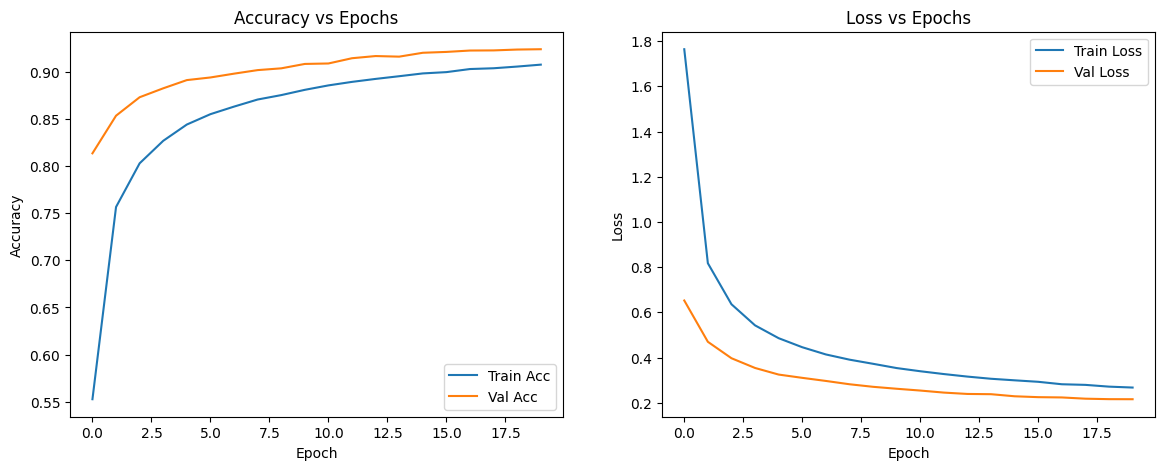

In [14]:
import matplotlib.pyplot as plt

def plot_training(history):
    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train Acc")
    plt.plot(history.history["val_accuracy"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs Epochs")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs Epochs")
    plt.legend()

    plt.show()

plot_training(history)


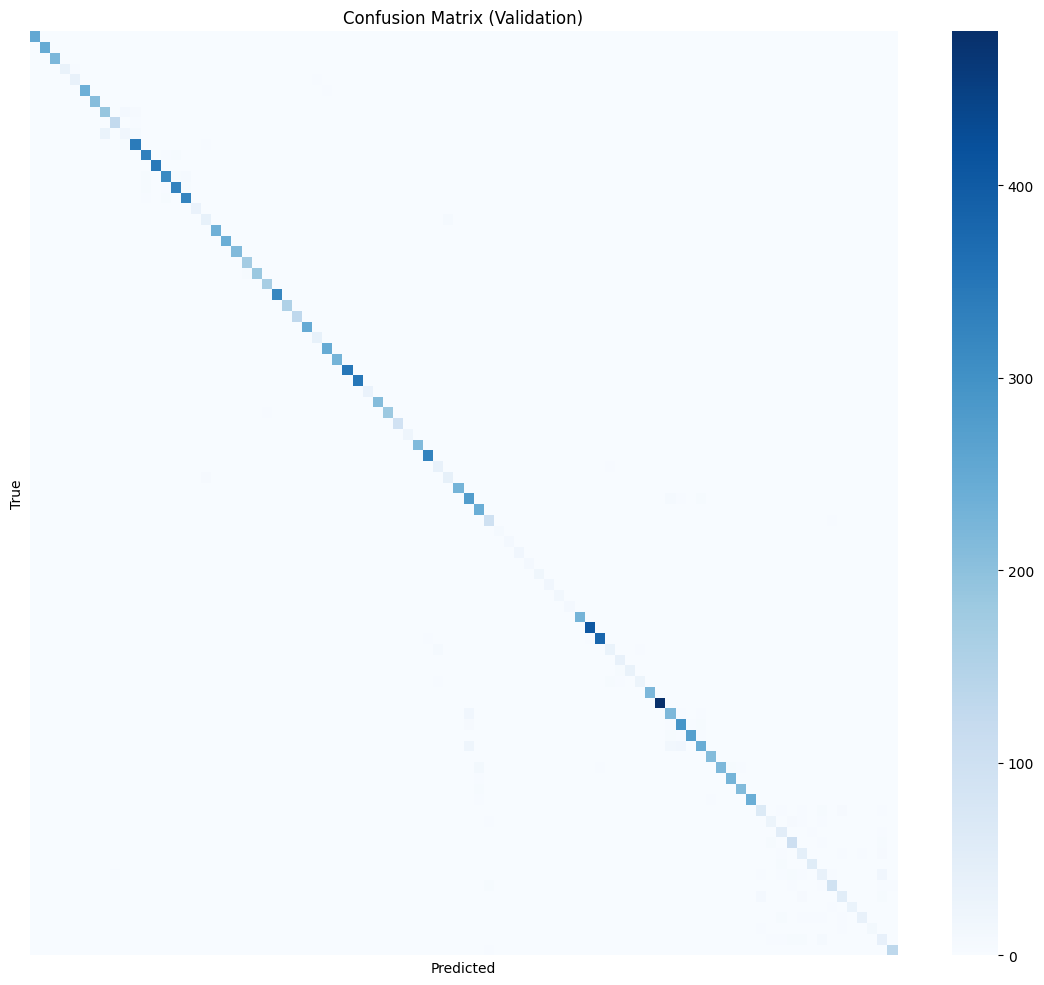

In [15]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Collect predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14,12))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation)")
plt.show()


In [16]:
MODEL_PATH = "/content/plant_disease_cnn.keras"
model.save(MODEL_PATH)
from google.colab import files
files.download(MODEL_PATH)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import tensorflow as tf

trained_model = tf.keras.models.load_model("plant_disease_cnn.keras")
trained_model.summary()
base_model = trained_model.get_layer("resnet50")
inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
x = tf.keras.applications.resnet50.preprocess_input(inputs)

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

inference_model = tf.keras.Model(inputs, outputs)
inference_model.set_weights(trained_model.get_weights())

converter = tf.lite.TFLiteConverter.from_keras_model(inference_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

tflite_model = converter.convert()

with open("plant_disease_fp16.tflite", "wb") as f:
    f.write(tflite_model)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_6 (Stack)     │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack_6[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 86)        │     22,102 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 54,144,392 (206.54 MB)

 Trainable params: 15,000,918 (57.22 MB)

 Non-trainable params: 9,141,632 (34.87 MB)

 Optimizer params: 30,001,842 (114.45 MB)

Saved artifact at '/tmp/tmpjlqtlk2y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_1827')
Output Type:
  TensorSpec(shape=(None, 86), dtype=tf.float16, name=None)
Captures:
  135322211992208: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135322213988688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135322213988304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135322213987920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135322213986960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135322213987152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135322213987728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135322213987344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135322213988112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135322213988496: TensorSpec(shape=(), dtype=tf.resource, name=None)
 

In [6]:
import tensorflow as tf
import numpy as np

interpreter = tf.lite.Interpreter(
    model_path="plant_disease_fp16.tflite"
)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_index = input_details[0]["index"]
output_index = output_details[0]["index"]

print("Input shape:", input_details[0]["shape"])
print("Output shape:", output_details[0]["shape"])


Input shape: [  1 224 224   3]
Output shape: [ 1 86]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
import tensorflow as tf
import numpy as np

test_ds = test_ds.unbatch()
test_ds = test_ds.batch(16, drop_remainder=True)
batch_size = 16

interpreter.resize_tensor_input(
    input_index,
    [batch_size, 224, 224, 3],
    strict=True
)
interpreter.allocate_tensors()
correct = 0
total = 0

for images, labels in test_ds:
    images = images.numpy().astype(np.float32)
    labels = labels.numpy()

    interpreter.set_tensor(input_index, images)
    interpreter.invoke()

    predictions = interpreter.get_tensor(output_index)

    pred_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(labels, axis=1)

    correct += np.sum(pred_classes == true_classes)
    total += images.shape[0]

accuracy = correct / total
print(f"TFLite FP16 Test Accuracy: {accuracy * 100:.2f}%")



In [ ]:
keras_loss, keras_acc = trained_model.evaluate(test_ds, verbose=0)
print(f"Keras Test Accuracy: {keras_acc * 100:.2f}%")
